# **🩻 Detecting Pneumonia: Deep Learning Classifier**
The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal).

Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.

For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.

### **Dataset Overview**
```text
chest_xray/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
├── test/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── val/
    ├── NORMAL/
    └── PNEUMONIA/

```

| Attribute | Details |
| --- | --- |
| **Total Images** | 5,863 JPEG files |
| **Target Classes** | 2 (`NORMAL` vs. `PNEUMONIA`) |
| **Patient Cohort** | Pediatric patients (1–5 years old) |
| **Source Institution** | Guangzhou Women and Children’s Medical Center |

```

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# Loop through the directories
for dirname, _, filenames in os.walk('/kaggle/input'):
    # Check if the folder actually contains files
    if filenames:
        print(f"\n📂 Directory: {dirname} (Showing first 5 files)")
        
        # Slice the list to only get the first 5 files
        for filename in filenames[:5]:
            print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


📂 Directory: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray (Showing first 5 files)
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store

📂 Directory: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val (Showing first 5 files)
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store

📂 Directory: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA (Showing first 5 files)
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# Verify GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("🚀 GPU is ready to accelerate training!")

# FIXED: Exact absolute path mapping based on your directory printout
BASE_DIR = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

print("✅ Base directories configured successfully.")

Num GPUs Available:  0
✅ Base directories configured successfully.


2026-07-18 10:37:05.255222: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


📊 Train Split -> Normal: 1341 | Pneumonia: 3875
📊 Val Split -> Normal: 8 | Pneumonia: 8
📊 Test Split -> Normal: 234 | Pneumonia: 390
Found 5216 files belonging to 2 classes.


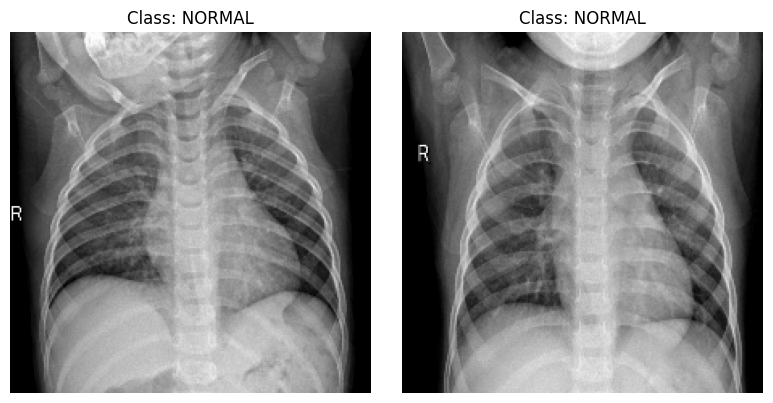

In [3]:
# Print dataset distribution counts cleanly
for split_path, split_name in [(TRAIN_DIR, "Train"), (VAL_DIR, "Val"), (TEST_DIR, "Test")]:
    norm_count = len([f for f in os.listdir(os.path.join(split_path, 'NORMAL')) if not f.startswith('.')])
    pneu_count = len([f for f in os.listdir(os.path.join(split_path, 'PNEUMONIA')) if not f.startswith('.')])
    print(f"📊 {split_name} Split -> Normal: {norm_count} | Pneumonia: {pneu_count}")

# Load a quick batch to visualize sample images
sample_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, batch_size=2, image_size=(224, 224), seed=42
)
class_names = sample_ds.class_names

plt.figure(figsize=(8, 4))
for images, labels in sample_ds.take(1):
    for i in range(2):
        plt.subplot(1, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Class: {class_names[labels[i]]}")
        plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Light augmentation pipeline for the training split
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Build datasets (Keras automatically ignores the hidden .DS_Store / __MACOSX files)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=False
)

# Apply data augmentation and optimize background prefetching memory lanes
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("✅ Preprocessing pipeline and datasets finalized!")

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
✅ Preprocessing pipeline and datasets finalized!


In [5]:
# Load pre-trained MobileNetV2 base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False  # Freeze weights

# Construct the custom model wrapper
inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs) # Scale inputs to [-1, 1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# Stop early if the tiny validation split accuracy halts
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

print("🟢 Training model...")
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=callbacks
)

🟢 Training model...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 950ms/step - accuracy: 0.8639 - loss: 0.3151 - recall: 0.9548 - val_accuracy: 0.5625 - val_loss: 0.6114 - val_recall: 1.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 151s 925ms/step - accuracy: 0.9331 - loss: 0.1791 - recall: 0.9631 - val_accuracy: 0.7500 - val_loss: 0.4925 - val_recall: 1.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 930ms/step - accuracy: 0.9434 - loss: 0.1517 - recall: 0.9665 - val_accuracy: 0.7500 - val_loss: 0.4763 - val_recall: 1.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 929ms/step - accuracy: 0.9413 - loss: 0.1450 - recall: 0.9605 - val_accuracy: 0.6875 - val_loss: 0.5927 - val_recall: 1.0000
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 928ms/step - accuracy: 0.9467 - loss: 0.1342 - recall: 0.9657 - val_accuracy: 0.8750 - val_loss: 0.3438 - val_recall: 1.0000
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 926ms/step - accuracy: 0.9463 - loss: 0.1322 - recall: 0.9667 - val_accuracy: 0.6875 

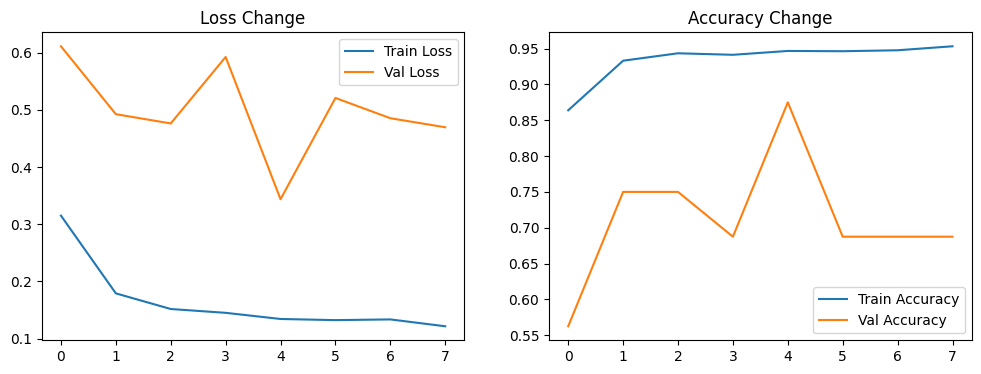


🔍 Evaluating Test Data Performance...
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 772ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.51      0.67       234
   Pneumonia       0.77      0.99      0.87       390

    accuracy                           0.81       624
   macro avg       0.87      0.75      0.77       624
weighted avg       0.84      0.81      0.79       624

🧱 Confusion Matrix:
[[120 114]
 [  5 385]]


In [7]:
# 1. Plot performance charts
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Change')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Change')
plt.show()

# 2. Extract true labels and compute evaluation statistics
print("\n🔍 Evaluating Test Data Performance...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
predictions = model.predict(test_ds)
y_pred = (predictions > 0.5).astype(int)

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

print("🧱 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))